In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import torch.nn as nn
import torch.nn.functional as F
import timm
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [11]:
class XceptionBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = timm.create_model(
            'xception41', pretrained=True, features_only=True, in_chans=4
        )

    def forward(self, x):
        features = self.model(x)
        return features[1], features[3]


class ASPP(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)


class ImprovedDeepLabV3Plus(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = XceptionBackbone()
        self.aspp = ASPP(1024, 256)
        self.final = nn.Conv2d(256, 1, 1)

    def forward(self, x):
        h, w = x.shape[-2:]
        low, high = self.backbone(x)
        x = self.aspp(high)
        x = F.interpolate(x, size=(h, w), mode='bilinear', align_corners=False)
        return torch.sigmoid(self.final(x))

In [12]:
model = ImprovedDeepLabV3Plus()

model.load_state_dict(
    torch.load("final1_model2.pth", map_location=device)
)

model = model.to(device)
model.eval()

print("✅ Model loaded")

✅ Model loaded


In [13]:
def cloud_cover_ratio(mask):
    total_pixels = mask.size
    cloud_pixels = np.sum(mask)
    return (cloud_pixels / total_pixels) * 100


def solar_irradiance_from_cloud(mask, I_max=1000.0, alpha=0.8):
    cloud_ratio = cloud_cover_ratio(mask) / 100.0
    irradiance = I_max * (1 - alpha * cloud_ratio)
    irradiance = max(irradiance, 0)
    return cloud_ratio * 100, irradiance


def to_rgb(image_4band):
    rgb = image_4band[[2, 1, 0], :, :]  # B04, B03, B02
    rgb = np.transpose(rgb, (1, 2, 0))
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    return rgb

In [14]:
test_dir = r"D:\Test"

bands = ['B02', 'B03', 'B04', 'B08']
features = []

for band in bands:
    path = os.path.join(test_dir, f"{band}.tif")
    with rasterio.open(path) as src:
        features.append(src.read(1).astype(np.float32))

image = np.stack(features, axis=-1)  # (H, W, 4)

print("✅ Image loaded:", image.shape)

✅ Image loaded: (516, 515, 4)


In [15]:
# Normalize like training
image = image / 65535.0
image = (image - 0.5) / 0.5

# Convert to tensor
image_t = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).float().to(device)

In [16]:
with torch.no_grad():
    output = model(image_t)
    pred = (output > 0.5).float()

pr = pred[0, 0].cpu().numpy()

print("✅ Prediction done")

✅ Prediction done


In [17]:
cloud_ratio, irradiance = solar_irradiance_from_cloud(pr)

print(f"🌥 Cloud Cover: {cloud_ratio:.2f}%")
print(f"☀ Estimated Irradiance: {irradiance:.2f} W/m²")

🌥 Cloud Cover: 30.24%
☀ Estimated Irradiance: 758.12 W/m²


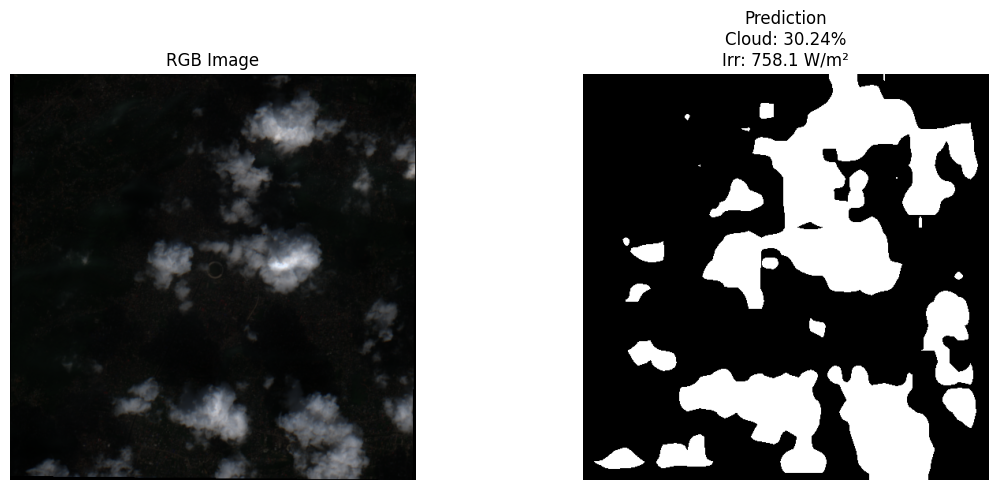

In [18]:
img = image_t[0].cpu().numpy()
rgb = to_rgb(img)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pr, cmap="gray")
plt.title(f"Prediction\nCloud: {cloud_ratio:.2f}%\nIrr: {irradiance:.1f} W/m²")
plt.axis("off")

plt.tight_layout()
plt.show()